In [1]:
import pandas as pd
import os

In [2]:
Base_Path = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\original_results\GeoRFResults"
Base_Path_XGB = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\original_results\GeoXgboostResults"

In [3]:
# find all folders contains _fs1_
all_folders = [f.path for f in os.scandir(Base_Path) if f.is_dir()]
fs1_folders = [f for f in all_folders if '_fs1_' in f]
fs2_folders = [f for f in all_folders if '_fs2_' in f]


#iterate all fs1 folders. find its subfolder vis, read and concate comprehensive_partition_metrics.csv
df_list = pd.DataFrame()
for folder in fs1_folders:
    vis_folder = os.path.join(folder, 'vis')
    csv_path = os.path.join(vis_folder, 'comprehensive_partition_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # keep only X_group, f1_before, folder
        df = df[['X_group', 'f1_before']]
        df_list = pd.concat([df_list, df], ignore_index=True)       
# group by X_group, get mean of f1_before
df_result = df_list.groupby('X_group').mean().reset_index()
# rename X_group as FEWSNET_admin_code
df_result = df_result.rename(columns={'X_group': 'FEWSNET_admin_code', 'f1_before': 'f1_unsplit'})
# write csv 
df_result.to_csv(os.path.join(Base_Path, 'f1_unsplit_by_admin_code_fs1.csv'), index=False)


In [4]:
df_list = pd.DataFrame()
for folder in fs2_folders:
    vis_folder = os.path.join(folder, 'vis')
    csv_path = os.path.join(vis_folder, 'comprehensive_partition_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # keep only X_group, f1_before, folder
        df = df[['X_group', 'f1_before']]
        df_list = pd.concat([df_list, df], ignore_index=True)       
# group by X_group, get mean of f1_before
df_result = df_list.groupby('X_group').mean().reset_index()
# rename X_group as FEWSNET_admin_code
df_result = df_result.rename(columns={'X_group': 'FEWSNET_admin_code', 'f1_before': 'f1_unsplit'})
# write csv 
df_result.to_csv(os.path.join(Base_Path, 'f1_unsplit_by_admin_code_fs2.csv'), index=False)

In [5]:
# find all folders contains _fs1_
all_folders = [f.path for f in os.scandir(Base_Path_XGB) if f.is_dir()]
fs1_folders = [f for f in all_folders if '_fs1_' in f]
fs2_folders = [f for f in all_folders if '_fs2_' in f]

#iterate all fs1 folders. find its subfolder vis, read and concate comprehensive_partition_metrics.csv
df_list = pd.DataFrame()
for folder in fs1_folders:
    vis_folder = os.path.join(folder, 'vis')
    csv_path = os.path.join(vis_folder, 'comprehensive_partition_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # keep only X_group, f1_before, folder
        df = df[['X_group', 'f1_before']]
        df_list = pd.concat([df_list, df], ignore_index=True)       
# group by X_group, get mean of f1_before
df_result = df_list.groupby('X_group').mean().reset_index()
# rename X_group as FEWSNET_admin_code
df_result = df_result.rename(columns={'X_group': 'FEWSNET_admin_code', 'f1_before': 'f1_unsplit'})
# write csv 
df_result.to_csv(os.path.join(Base_Path_XGB, 'f1_unsplit_by_admin_code_fs1.csv'), index=False)


In [6]:
#iterate all fs1 folders. find its subfolder vis, read and concate comprehensive_partition_metrics.csv
df_list = pd.DataFrame()
for folder in fs2_folders:
    vis_folder = os.path.join(folder, 'vis')
    csv_path = os.path.join(vis_folder, 'comprehensive_partition_metrics.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # keep only X_group, f1_before, folder
        df = df[['X_group', 'f1_before']]
        df_list = pd.concat([df_list, df], ignore_index=True)       
# group by X_group, get mean of f1_before
df_result = df_list.groupby('X_group').mean().reset_index()
# rename X_group as FEWSNET_admin_code
df_result = df_result.rename(columns={'X_group': 'FEWSNET_admin_code', 'f1_before': 'f1_unsplit'})
# write csv 
df_result.to_csv(os.path.join(Base_Path_XGB, 'f1_unsplit_by_admin_code_fs2.csv'), index=False)

In [7]:
# load both fs1 and fs2 f1 unsplit csvs, merge on FEWSNET_admin_code, compare f1_unsplit
df_fs1 = pd.read_csv(os.path.join(Base_Path, 'f1_unsplit_by_admin_code_fs1.csv'))
df_fs2 = pd.read_csv(os.path.join(Base_Path, 'f1_unsplit_by_admin_code_fs2.csv'))
df_XGB_fs1 = pd.read_csv(os.path.join(Base_Path_XGB, 'f1_unsplit_by_admin_code_fs1.csv'))
df_XGB_fs2 = pd.read_csv(os.path.join(Base_Path_XGB, 'f1_unsplit_by_admin_code_fs2.csv'))
#read split results
BASE_split_path = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\deliverables\test_spatial_weighted_month_independent\result_partition_k40_nc4_compare"
df_split_fs1 = pd.read_csv(os.path.join(BASE_split_path, 'metrics_polygon_overall_lag1.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs1 = df_split_fs1[['FEWSNET_admin_code', 'f1_partitioned']]
df_split_fs2 = pd.read_csv(os.path.join(BASE_split_path, 'metrics_polygon_overall_lag2.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs2 = df_split_fs2[['FEWSNET_admin_code', 'f1_partitioned']]

BASE_split_path_XGB = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\deliverables\test_spatial_weighted_month_independent\result_partition_k40_nc4_compare_XGB"
df_split_fs1_XGB = pd.read_csv(os.path.join(BASE_split_path_XGB, 'metrics_polygon_overall_lag1.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs1_XGB = df_split_fs1_XGB[['FEWSNET_admin_code', 'f1_partitioned']]
df_split_fs2_XGB = pd.read_csv(os.path.join(BASE_split_path_XGB, 'metrics_polygon_overall_lag2.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs2_XGB = df_split_fs2_XGB[['FEWSNET_admin_code', 'f1_partitioned']]

In [8]:
# rename columns before merge
df_fs1 = df_fs1.rename(columns={'f1_unsplit': 'f1_unsplit_fs1'})
df_fs2 = df_fs2.rename(columns={'f1_unsplit': 'f1_unsplit_fs2'})
df_XGB_fs1 = df_XGB_fs1.rename(columns={'f1_unsplit': 'f1_unsplit_fs1_XGB'})
df_XGB_fs2 = df_XGB_fs2.rename(columns={'f1_unsplit': 'f1_unsplit_fs2_XGB'})
df_split_fs1 = df_split_fs1.rename(columns={'f1_partitioned': 'f1_split_fs1'})
df_split_fs2 = df_split_fs2.rename(columns={'f1_partitioned': 'f1_split_fs2'})
df_split_fs1_XGB = df_split_fs1_XGB.rename(columns={'f1_partitioned': 'f1_split_fs1_XGB'})
df_split_fs2_XGB = df_split_fs2_XGB.rename(columns={'f1_partitioned': 'f1_split_fs2_XGB'})

In [9]:
# merge on FEWSNET_admin_code
df_merged = df_fs1.merge(df_fs2, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_XGB_fs1, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_XGB_fs2, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_split_fs1, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_split_fs2, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_split_fs1_XGB, on='FEWSNET_admin_code', how='outer')
df_merged = df_merged.merge(df_split_fs2_XGB, on='FEWSNET_admin_code', how='outer')

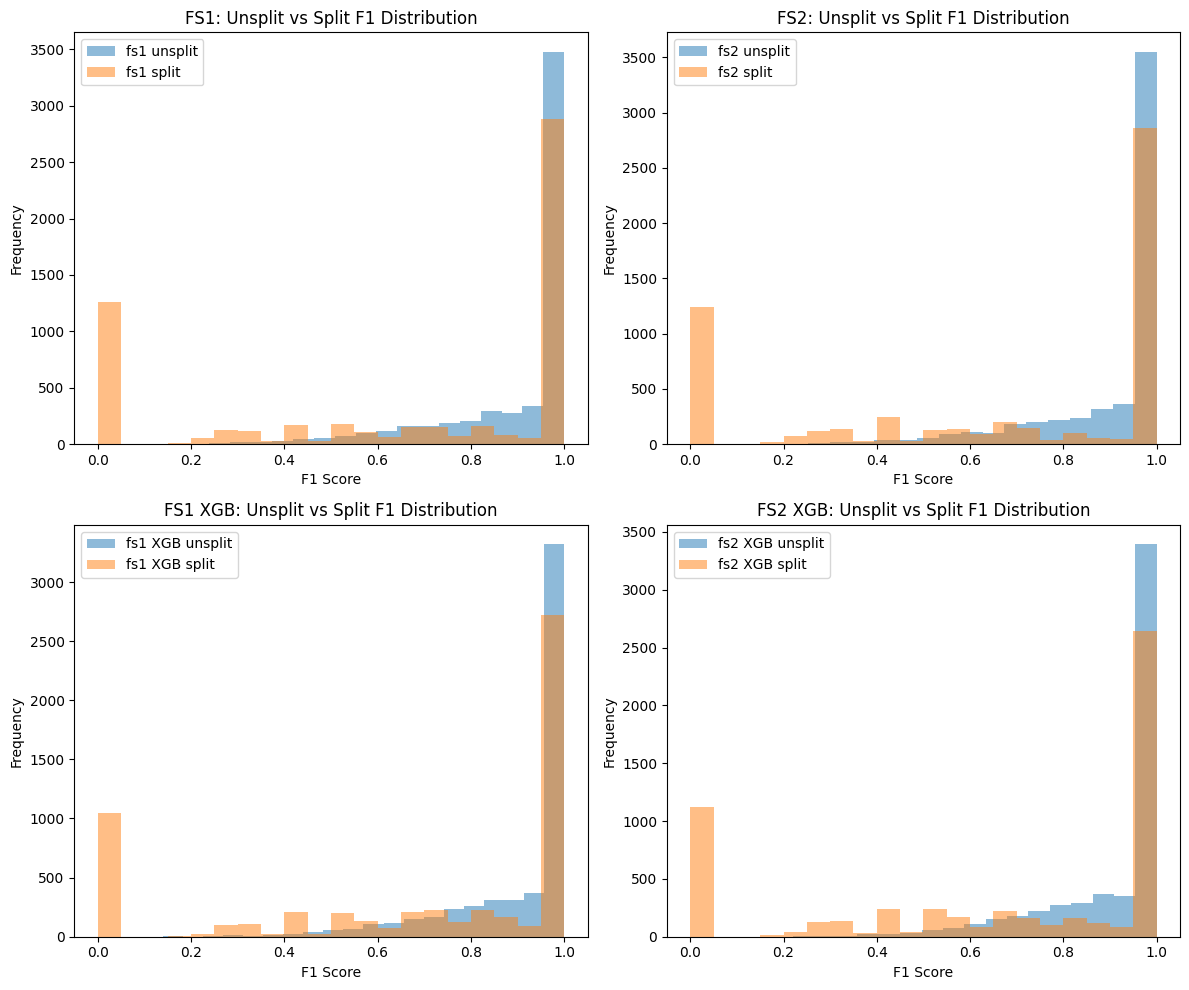

In [10]:
# plot 2*2 subplots to compare f1 distribution, from left to right, top to bottom: fs1 unsplit vs fs1 split, fs2 unsplit vs fs2 split, fs1 XGB unsplit vs fs1 XGB split, fs2 XGB unsplit vs fs2 XGB split
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].hist(df_merged['f1_unsplit_fs1'], bins=20, alpha=0.5, label='fs1 unsplit')
axs[0, 0].hist(df_merged['f1_split_fs1'], bins=20, alpha=0.5, label='fs1 split')
axs[0, 0].set_title('FS1: Unsplit vs Split F1 Distribution')
axs[0, 0].set_xlabel('F1 Score')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].legend()
axs[0, 1].hist(df_merged['f1_unsplit_fs2'], bins=20, alpha=0.5, label='fs2 unsplit')
axs[0, 1].hist(df_merged['f1_split_fs2'], bins=20, alpha=0.5, label='fs2 split')
axs[0, 1].set_title('FS2: Unsplit vs Split F1 Distribution')
axs[0, 1].set_xlabel('F1 Score')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].legend()
axs[1, 0].hist(df_merged['f1_unsplit_fs1_XGB'], bins=20, alpha=0.5, label='fs1 XGB unsplit')
axs[1, 0].hist(df_merged['f1_split_fs1_XGB'], bins=20, alpha=0.5, label='fs1 XGB split')
axs[1, 0].set_title('FS1 XGB: Unsplit vs Split F1 Distribution')
axs[1, 0].set_xlabel('F1 Score')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].legend()
axs[1, 1].hist(df_merged['f1_unsplit_fs2_XGB'], bins=20, alpha=0.5, label='fs2 XGB unsplit')
axs[1, 1].hist(df_merged['f1_split_fs2_XGB'], bins=20, alpha=0.5, label='fs2 XGB split')
axs[1, 1].set_title('FS2 XGB: Unsplit vs Split F1 Distribution')
axs[1, 1].set_xlabel('F1 Score')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].legend()
plt.tight_layout()
plt.show()




In [4]:
import pandas as pd
import os

In [5]:
BASE_split_path = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\deliverables\test_spatial_weighted_month_independent\result_partition_k40_nc4_compare"
df_split_fs1 = pd.read_csv(os.path.join(BASE_split_path, 'metrics_polygon_overall_lag1.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs1 = df_split_fs1[['FEWSNET_admin_code', 'f1_partitioned','f1_pooled']]
df_split_fs2 = pd.read_csv(os.path.join(BASE_split_path, 'metrics_polygon_overall_lag2.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs2 = df_split_fs2[['FEWSNET_admin_code', 'f1_partitioned','f1_pooled']]

BASE_split_path_XGB = r"C:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\2.source_code\Step5_Geo_RF_trial\Food_Crisis_Cluster\deliverables\test_spatial_weighted_month_independent\result_partition_k40_nc4_compare_XGB"
df_split_fs1_XGB = pd.read_csv(os.path.join(BASE_split_path_XGB, 'metrics_polygon_overall_lag1.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs1_XGB = df_split_fs1_XGB[['FEWSNET_admin_code', 'f1_partitioned','f1_pooled']]
df_split_fs2_XGB = pd.read_csv(os.path.join(BASE_split_path_XGB, 'metrics_polygon_overall_lag2.csv'))
#keep only FEWSNET_admin_code and f1_partitioned
df_split_fs2_XGB = df_split_fs2_XGB[['FEWSNET_admin_code', 'f1_partitioned','f1_pooled']]

In [6]:
# rename columns before merge
df_split_fs1 = df_split_fs1.rename(columns={'f1_partitioned': 'f1_split_fs1','f1_pooled':'f1_pooled_fs1'})
df_split_fs2 = df_split_fs2.rename(columns={'f1_partitioned': 'f1_split_fs2','f1_pooled':'f1_pooled_fs2'})
df_split_fs1_XGB = df_split_fs1_XGB.rename(columns={'f1_partitioned': 'f1_split_fs1_XGB','f1_pooled':'f1_pooled_fs1_XGB'})
df_split_fs2_XGB = df_split_fs2_XGB.rename(columns={'f1_partitioned': 'f1_split_fs2_XGB','f1_pooled':'f1_pooled_fs2_XGB'})

In [7]:
# merge on FEWSNET_admin_code
df_merged_2 = df_split_fs1.merge(df_split_fs2, on='FEWSNET_admin_code', how='outer')
df_merged_2 = df_merged_2.merge(df_split_fs1_XGB, on='FEWSNET_admin_code', how='outer')
df_merged_2 = df_merged_2.merge(df_split_fs2_XGB, on='FEWSNET_admin_code', how='outer')

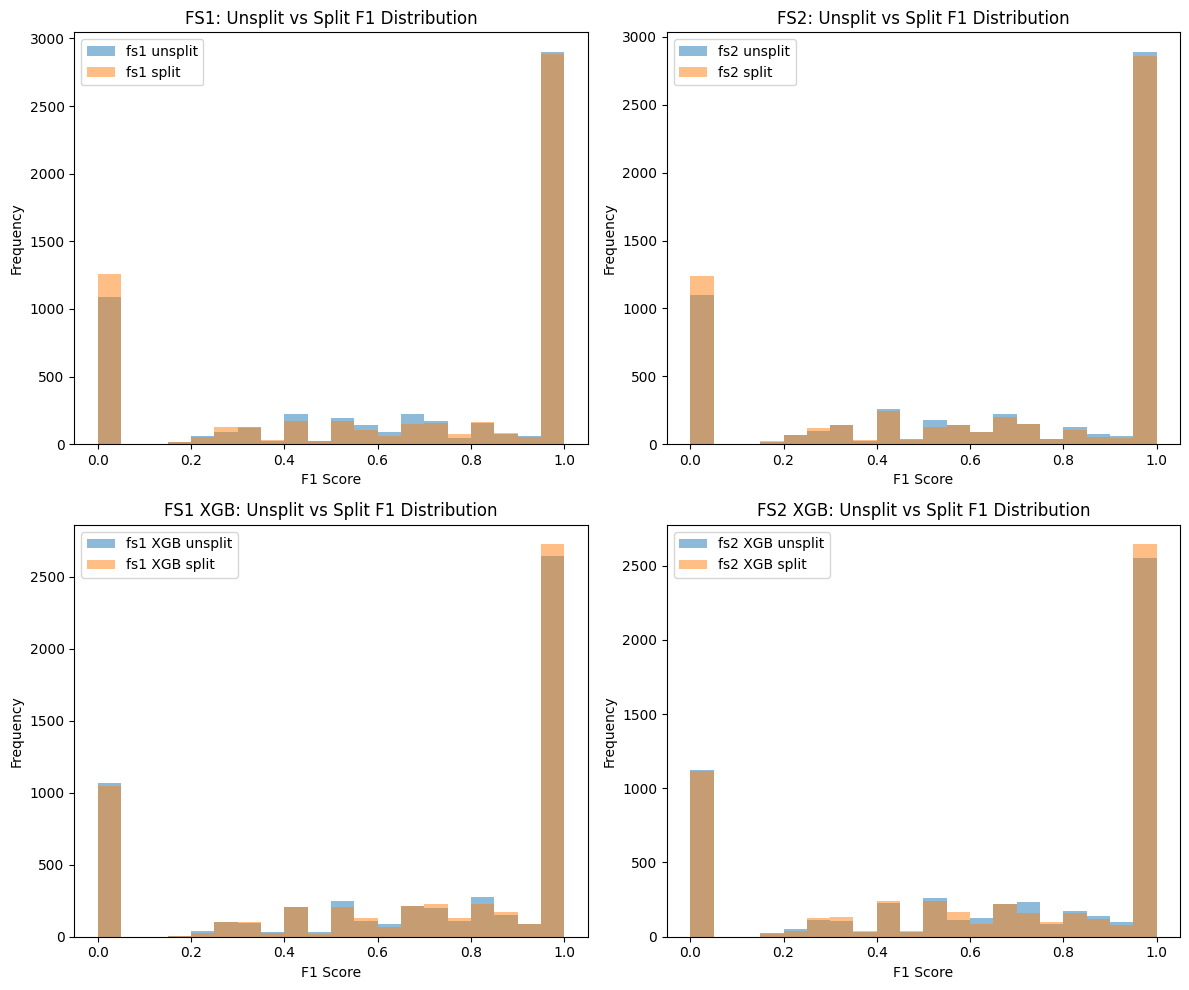

In [8]:
# plot 2*2 subplots to compare f1 distribution, from left to right, top to bottom: fs1 unsplit vs fs1 split, fs2 unsplit vs fs2 split, fs1 XGB unsplit vs fs1 XGB split, fs2 XGB unsplit vs fs2 XGB split
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].hist(df_merged_2['f1_pooled_fs1'], bins=20, alpha=0.5, label='fs1 unsplit')
axs[0, 0].hist(df_merged_2['f1_split_fs1'], bins=20, alpha=0.5, label='fs1 split')
axs[0, 0].set_title('FS1: Unsplit vs Split F1 Distribution')
axs[0, 0].set_xlabel('F1 Score')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].legend()
axs[0, 1].hist(df_merged_2['f1_pooled_fs2'], bins=20, alpha=0.5, label='fs2 unsplit')
axs[0, 1].hist(df_merged_2['f1_split_fs2'], bins=20, alpha=0.5, label='fs2 split')
axs[0, 1].set_title('FS2: Unsplit vs Split F1 Distribution')
axs[0, 1].set_xlabel('F1 Score')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].legend()
axs[1, 0].hist(df_merged_2['f1_pooled_fs1_XGB'], bins=20, alpha=0.5, label='fs1 XGB unsplit')
axs[1, 0].hist(df_merged_2['f1_split_fs1_XGB'], bins=20, alpha=0.5, label='fs1 XGB split')
axs[1, 0].set_title('FS1 XGB: Unsplit vs Split F1 Distribution')
axs[1, 0].set_xlabel('F1 Score')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].legend()
axs[1, 1].hist(df_merged_2['f1_pooled_fs2_XGB'], bins=20, alpha=0.5, label='fs2 XGB unsplit')
axs[1, 1].hist(df_merged_2['f1_split_fs2_XGB'], bins=20, alpha=0.5, label='fs2 XGB split')
axs[1, 1].set_title('FS2 XGB: Unsplit vs Split F1 Distribution')
axs[1, 1].set_xlabel('F1 Score')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].legend()
plt.tight_layout()
plt.show()

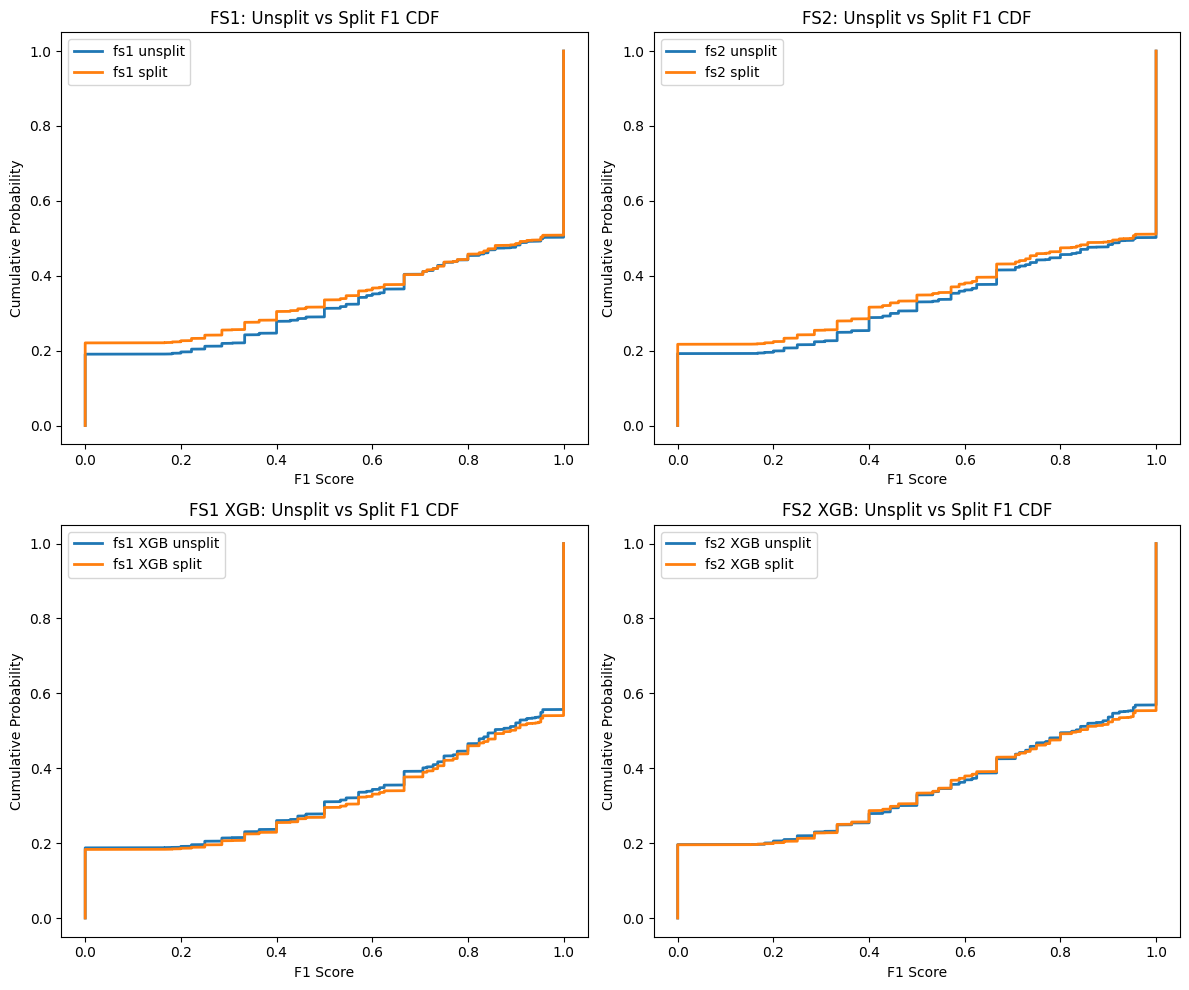

In [15]:
# plot cdf of f1 scores: unsplit vs split for fs1 and fs2 use line only
import numpy as np
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# FS1
for ax in axs[0]:
    for line in ax.lines:
        line.set_linewidth(2)
axs[0, 0].plot(np.sort(df_merged_2['f1_pooled_fs1']), np.linspace(0, 1, len(df_merged_2['f1_pooled_fs1'])), label='fs1 unsplit', linewidth=2)
axs[0, 0].plot(np.sort(df_merged_2['f1_split_fs1']), np.linspace(0, 1, len(df_merged_2['f1_split_fs1'])), label='fs1 split', linewidth=2)
axs[0, 0].set_title('FS1: Unsplit vs Split F1 CDF')
axs[0, 0].set_xlabel('F1 Score')
axs[0, 0].set_ylabel('Cumulative Probability')
axs[0, 0].legend()
axs[0, 1].plot(np.sort(df_merged_2['f1_pooled_fs2']), np.linspace(0, 1, len(df_merged_2['f1_pooled_fs2'])), label='fs2 unsplit', linewidth=2)
axs[0, 1].plot(np.sort(df_merged_2['f1_split_fs2']), np.linspace(0, 1, len(df_merged_2['f1_split_fs2'])), label='fs2 split', linewidth=2)
axs[0, 1].set_title('FS2: Unsplit vs Split F1 CDF')
axs[0, 1].set_xlabel('F1 Score')
axs[0, 1].set_ylabel('Cumulative Probability')
axs[0, 1].legend()
axs[1, 0].plot(np.sort(df_merged_2['f1_pooled_fs1_XGB']), np.linspace(0, 1, len(df_merged_2['f1_pooled_fs1_XGB'])), label='fs1 XGB unsplit', linewidth=2)
axs[1, 0].plot(np.sort(df_merged_2['f1_split_fs1_XGB']), np.linspace(0, 1, len(df_merged_2['f1_split_fs1_XGB'])), label='fs1 XGB split', linewidth=2)
axs[1, 0].set_title('FS1 XGB: Unsplit vs Split F1 CDF')
axs[1, 0].set_xlabel('F1 Score')
axs[1, 0].set_ylabel('Cumulative Probability')
axs[1, 0].legend()
axs[1, 1].plot(np.sort(df_merged_2['f1_pooled_fs2_XGB']), np.linspace(0, 1, len(df_merged_2['f1_pooled_fs2_XGB'])), label='fs2 XGB unsplit', linewidth=2)
axs[1, 1].plot(np.sort(df_merged_2['f1_split_fs2_XGB']), np.linspace(0, 1, len(df_merged_2['f1_split_fs2_XGB'])), label='fs2 XGB split', linewidth=2)
axs[1, 1].set_title('FS2 XGB: Unsplit vs Split F1 CDF')
axs[1, 1].set_xlabel('F1 Score')
axs[1, 1].set_ylabel('Cumulative Probability')
axs[1, 1].legend()
plt.tight_layout()
plt.show()
